## ANALISIS DE ESPERANZA DE VIDA (2000-2015)

**Fuente:** Organización Mundial de la Salud (OMS) | **Dataset:** Kaggle - Life Expectancy WHO

## Contexto
La esperanza de vida es uno de los indicadores más importantes del bienestar de una población.
No depende de un solo factor, sino de una combinación de condiciones sanitarias, económicas y sociales.

## Objetivo
Identificar qué factores sociosanitarios influyen más en la esperanza de vida de un país,
y construir un modelo de regresión lineal capaz de predecirla.

## Preguntas que guían el análisis
- ¿Qué variables tienen mayor correlación con la esperanza de vida?
- ¿Existe una diferencia significativa entre países desarrollados y en desarrollo?
- ¿El gasto en salud realmente impacta en cuánto vive la gente?
- ¿Podemos predecir la esperanza de vida con un modelo lineal?

## Herramientas utilizadas
`Python` | `Pandas` | `NumPy` | `Matplotlib` | `Seaborn` | `Scikit-learn`

In [55]:
# IMPORTAMOS LAS LIBRERIAS NECESARIAS PARA EL ANALISIS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

In [56]:
# CARGAMOS Y LEEMOS EL CSV 
le = pd.read_csv('Life Expectancy Data.csv')

## LIMPIEZA DE DATOS
Organizamos el DF de forma que no queden valores posiblemente problemáticos para el resto del análisis

In [57]:
# LIMPIAMOS ESPACIOS DE LAS COLUMNAS 
le.columns = le.columns.str.strip()

In [58]:
# VEMOS VALORES NULOS
(le[le.select_dtypes(include='number').columns] == 0).sum()

Year                                 0
Life expectancy                      0
Adult Mortality                      0
infant deaths                      848
Alcohol                              0
percentage expenditure             611
Hepatitis B                          0
Measles                            983
BMI                                  0
under-five deaths                  785
Polio                                0
Total expenditure                    0
Diphtheria                           0
HIV/AIDS                             0
GDP                                  0
Population                           0
thinness  1-19 years                 0
thinness 5-9 years                   0
Income composition of resources    130
Schooling                           28
dtype: int64

In [59]:
# LIMPIAMOS CEROS
def limpiar_ceros(le, columnas):
    for col in columnas:
        le[col] = le[col].replace(0, np.nan)
    return le


In [60]:
cols_limpiar = ['GDP', 'Population', 'Alcohol', 'BMI', 
                'percentage expenditure', 'Total expenditure', 'Schooling','Income composition of resources']
                
                

In [61]:
le = limpiar_ceros(le, cols_limpiar)

In [62]:
# VERIFICAMOS QUE NUESTRAS COLUMNAS ESTEN CORRECTAMENTE LIMPIAS
(le[le.select_dtypes(include='number').columns] == 0).sum()

Year                                 0
Life expectancy                      0
Adult Mortality                      0
infant deaths                      848
Alcohol                              0
percentage expenditure               0
Hepatitis B                          0
Measles                            983
BMI                                  0
under-five deaths                  785
Polio                                0
Total expenditure                    0
Diphtheria                           0
HIV/AIDS                             0
GDP                                  0
Population                           0
thinness  1-19 years                 0
thinness 5-9 years                   0
Income composition of resources      0
Schooling                            0
dtype: int64

In [63]:
# IMPUTAMOS LOS NAN CON MEDIANA PARA NO PERDER DATOS 
def imputar_medianas(df):
    cols_numericas = df.select_dtypes(include='number').columns
    for col in cols_numericas:
        df[col] = df[col].fillna((df[col].median()))
    return df

le = imputar_medianas(le)

In [64]:
# VISUALIZAMOS LAS PRIMERAS FILAS DEL DF
le.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [65]:
# OBTENEMOS INFO GENERAL DEL DF 


In [66]:
le.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2938 non-null   float64
 4   Adult Mortality                  2938 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2938 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2938 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2938 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [67]:
# CANTIDAD TOTAL DE PAISES
le['Country'].nunique() 

193

## COMENZAMOS EL ANALISIS VERDADERO
Realizamos una serie de *TOPS* interanuales sobre las categorías mas relevantes, para obtener un paneo general de la información, y distinguir
los primeros matices de interés

## *TOPS POR SALUD*

In [68]:
# TOP 10 PAISES CON MAYOR PROMEDIO DE CONSUMO DE ALCOHOL 
le.groupby('Country')['Alcohol'].mean().sort_values(ascending=False).head(10)

Country
Belarus       12.888438
Czechia       12.446563
Ireland       12.097812
Lithuania     12.077813
Croatia       11.904687
France        11.864062
Austria       11.705937
Portugal      11.682813
Luxembourg    11.411563
Germany       11.136563
Name: Alcohol, dtype: float64

In [69]:
# TOP 10 PAISES CON ESPERANZA DE VIDA MAS ALTA 
le.groupby('Country')['Life expectancy'].mean().sort_values(ascending=False).head(10)

Country
Japan          82.53750
Sweden         82.51875
Iceland        82.44375
Switzerland    82.33125
France         82.21875
Italy          82.18750
Spain          82.06875
Australia      81.81250
Norway         81.79375
Canada         81.68750
Name: Life expectancy, dtype: float64

In [70]:
# TOP 10 CON ESPERANZA MAS BAJA
le.groupby('Country')['Life expectancy'].mean().sort_values(ascending=True).head(10)

Country
Sierra Leone                46.11250
Central African Republic    48.51250
Lesotho                     48.78125
Angola                      49.01875
Malawi                      49.89375
Chad                        50.38750
Côte d'Ivoire               50.38750
Zimbabwe                    50.48750
Swaziland                   51.32500
Nigeria                     51.35625
Name: Life expectancy, dtype: float64

## *TOPS POR MORTALIDAD*

In [71]:
# TOP 10 PAISES CON MAYOR TASA DE MORTALIDAD ADULTA 
le.groupby('Country')['Adult Mortality'].mean().sort_values(ascending=False).head(10)

Country
Lesotho          550.0625
Zimbabwe         462.3750
Botswana         448.1250
Malawi           424.4375
Côte d'Ivoire    417.3125
South Africa     412.7500
Sierra Leone     357.8125
Zambia           354.3125
Kenya            348.5625
South Sudan      346.3125
Name: Adult Mortality, dtype: float64

In [72]:
# TOP 10 PAISES CON MAYOR TASA DE MORTALIDAD PREMATURA (BEBES)
le.groupby('Country')['infant deaths'].mean().sort_values(ascending=False).head(10)


Country
India                               1366.6875
Nigeria                              535.6875
Pakistan                             367.9375
China                                294.8750
Democratic Republic of the Congo     234.5000
Ethiopia                             187.7500
Bangladesh                           153.6250
Indonesia                            151.1875
United Republic of Tanzania           95.2500
Uganda                                89.6875
Name: infant deaths, dtype: float64

In [73]:
# TOP 10 PAISES CON MAYOR TASA DE MORTALIDAD INFANTIL (MENORES DE 5 AÑOS)
le.groupby('Country')['under-five deaths'].mean().sort_values(ascending=False).head(10)

Country
India                               1812.5000
Nigeria                              852.0625
Pakistan                             461.0000
China                                350.0000
Democratic Republic of the Congo     323.5000
Ethiopia                             288.5000
Bangladesh                           201.5625
Indonesia                            186.6250
United Republic of Tanzania          143.1875
Uganda                               138.8750
Name: under-five deaths, dtype: float64

## *TOPS POR ENFERMEDADES/VACUNACIÓN*

In [74]:
# TOP 10 PAISES CON MAYOR PROMEDIO DE MUERTES POR HIV/AIDS
le.groupby('Country')['HIV/AIDS'].mean().sort_values(ascending=False).head(10)

Country
Swaziland                   32.94375
Zimbabwe                    23.26250
Lesotho                     22.96875
South Africa                18.49375
Malawi                      16.68125
Botswana                    16.52500
Namibia                     13.64375
Zambia                      11.93125
Mozambique                  11.38750
Central African Republic     8.98125
Name: HIV/AIDS, dtype: float64

In [75]:
# TOP 10 PAISES CON MENOR % DE COBERTURA DE VACUNACION CONTRA HEPATITIS B EN NIÑOS
le.groupby('Country')['Hepatitis B'].mean().sort_values(ascending=True).head(10)

Country
Marshall Islands     8.0000
Tuvalu               9.0000
Canada              40.6875
India               49.2500
France              51.2500
Ukraine             54.6250
Samoa               54.9375
Yemen               55.6875
Vanuatu             56.1250
Papua New Guinea    57.0000
Name: Hepatitis B, dtype: float64

In [76]:
# TOP 10 PAISES CON MENOR % DE COBERTURA DE VACUNACION CONTRA POLIO 
le.groupby('Country')['Polio'].mean().sort_values(ascending=True).head(10)

Country
Tuvalu                       9.0000
Somalia                     29.8125
Chad                        32.8750
Equatorial Guinea           36.8750
Central African Republic    41.3125
Nigeria                     41.3125
Angola                      46.1250
Afghanistan                 48.3750
Ethiopia                    51.1250
Guinea                      52.4375
Name: Polio, dtype: float64

In [77]:
# TOP 10 PAISES CON MENOR % DE COBERTURA DE VACUNACION CONTRA DIFTERIA 
le.groupby('Country')['Diphtheria'].mean().sort_values(ascending=True).head(10)

Country
Tuvalu                               9.0000
Chad                                26.8125
Somalia                             29.3125
Equatorial Guinea                   29.9375
Nigeria                             39.3125
Liberia                             40.6875
Democratic Republic of the Congo    41.8750
Central African Republic            42.4375
Ethiopia                            46.1875
Angola                              47.6875
Name: Diphtheria, dtype: float64

In [78]:
# TOP 10 PAISES CON MAYOR PROMEDIO DE CASOS DE SARAMPION REPORTADOS
le.groupby('Country')['Measles'].mean().sort_values(ascending=False).head(10)

Country
China                               65857.9375
Nigeria                             51653.9375
Democratic Republic of the Congo    48922.6875
India                               46454.1875
Indonesia                           16244.9375
Niger                               15467.1250
Uganda                              12394.6250
Madagascar                           9576.1875
Malawi                               7559.4375
Philippines                          7144.6875
Name: Measles, dtype: float64

## *TOPS POR ECONOMIA*

In [79]:
# TOP 10 PAISES CON MAS INVERSION EN SALUD COMO % DEL PBI
le.groupby('Country')['percentage expenditure'].mean().sort_values(ascending=False).head(10)

Country
Switzerland    9811.510078
Luxembourg     8187.276042
Australia      5341.926173
Denmark        5323.035495
Iceland        5001.295009
Austria        4938.138889
Ireland        4877.012305
Canada         4703.778672
Norway         4668.513619
Sweden         4447.862854
Name: percentage expenditure, dtype: float64

In [80]:
# TOP 10 CON MENOR INVERSION
le.groupby('Country')['percentage expenditure'].mean().sort_values(ascending=True,).head(10)

Country
Dominica       11.419555
Nauru          15.606596
Myanmar        22.524264
Burundi        25.035198
Guinea         25.590983
Tajikistan     26.976893
Niger          28.799069
Rwanda         29.891054
Timor-Leste    30.887224
Senegal        31.186127
Name: percentage expenditure, dtype: float64

In [81]:
# TOP 10 PAISES CON MAYOR PBI PER CÁPITA EN DÓLARES 
le.groupby('Country')['GDP'].mean().sort_values(ascending=False,).head(10)

Country
Switzerland    57362.874601
Luxembourg     53257.012741
Qatar          40748.444104
Netherlands    34964.719797
Australia      34637.565047
Ireland        33835.272005
Austria        33827.476309
Denmark        33067.407916
Singapore      32790.105907
Kuwait         31914.378339
Name: GDP, dtype: float64

In [82]:
# TOP 10 CON MENOR PBI 
le.groupby('Country')['GDP'].mean().sort_values(ascending=True,).head(10)

Country
Nauru           136.183210
Burundi         137.815321
Malawi          237.504042
Liberia         246.281748
Niger           259.782441
Ethiopia        264.970950
Sierra Leone    271.505561
Senegal         274.611166
Guinea          279.464798
Rwanda          300.018017
Name: GDP, dtype: float64

## PRIMER PANEO 

A simple vista estos datos nos muestran algunos patrones interesantes:

-*Los paises europeos suelen encabezar las listas de inversion en salud*

-*Las listas "negativas" estan lideradas en su mayoria por paises africanos*


Esto ya divide el análisis en dos extremos, el sector más perjudicado y el más próspero.
Sin embargo, el motivo del análisis es tener una idea MUNDIAL, no solamente centrarse en uno u otro de los extremos

## PRIMERAS VISUALIZACIONES 

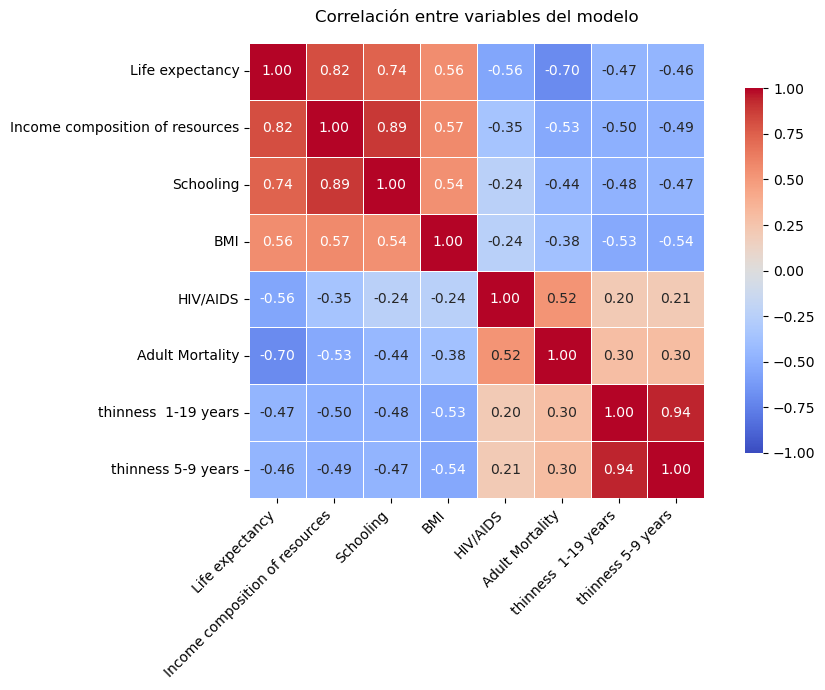

In [83]:
# HEATMAP DE CORRELACIONES 
vars_modelo = ['Life expectancy', 'Income composition of resources', 
               'Schooling', 'BMI', 'HIV/AIDS', 
               'Adult Mortality', 'thinness  1-19 years', 'thinness 5-9 years']

corr_matrix = le[vars_modelo].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlación entre variables del modelo', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


In [84]:
# GRAFICO TOP 10 PAISES CON MENOR ESPERANZA DE VIDA

In [85]:
top10 = (
    le.groupby('Country')['Life expectancy']
    .mean()
    .sort_values(ascending=True)
    .head(10)
    .reset_index()
)

Text(0.5, 1.0, 'Top 10 países con menor esperanza de vida')

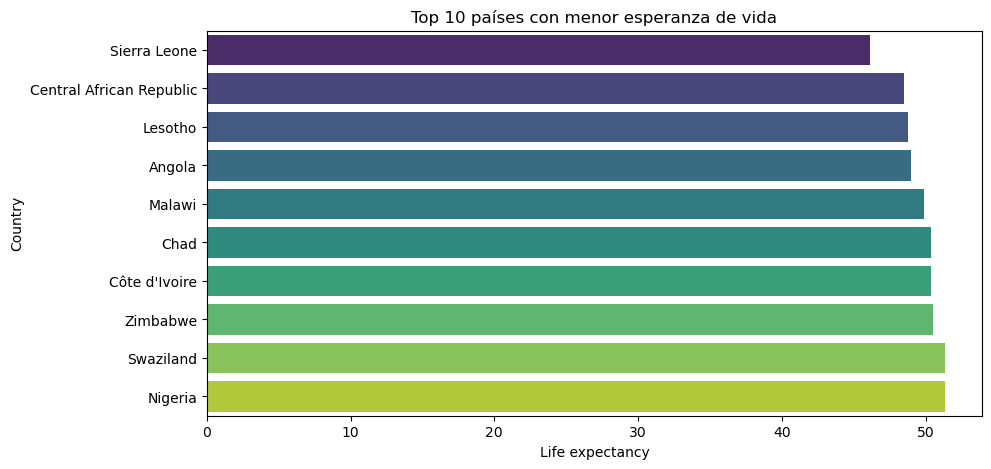

In [86]:


plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x='Life expectancy',
    y='Country',
    palette = 'viridis',
    hue='Country',
    legend=False
)

plt.title('Top 10 países con menor esperanza de vida')


In [87]:
# GRAFICO TOP 10 PAISES CON MAYOR INVERSION EN SALUD 


In [88]:
top10= (
    le.groupby('Country')['percentage expenditure']
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
)

Text(0.5, 1.0, 'Top 10 paises con mayor inversion en salud')

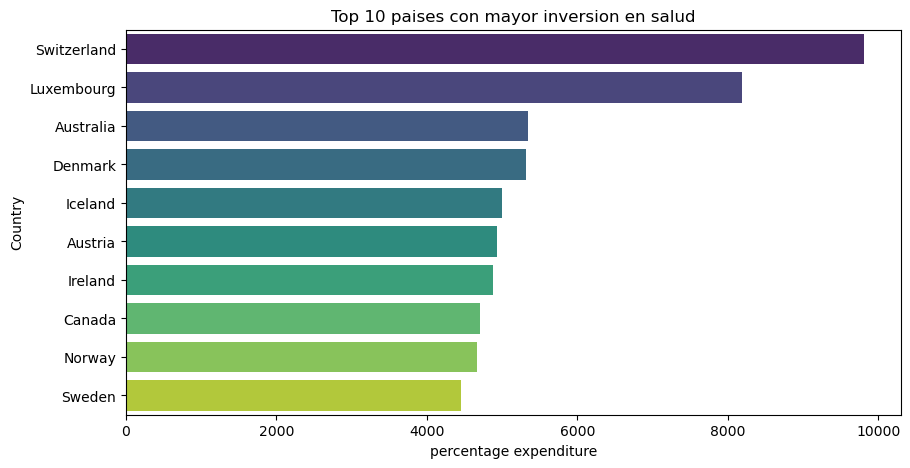

In [89]:
plt.figure(figsize=(10,5))

sns.barplot (
    data= top10,
    x= 'percentage expenditure',
    y='Country',
    palette= 'viridis',
    hue='Country',
    legend=False
)
plt.title('Top 10 paises con mayor inversion en salud')

In [90]:
# EVOLUCION DE LA ESPERANZA DE VIDA A TRAVES DE LOS AÑOS 


Text(0.5, 1.0, 'Evolucion de la esperanza de vida a traves de los años (2000-2015)')

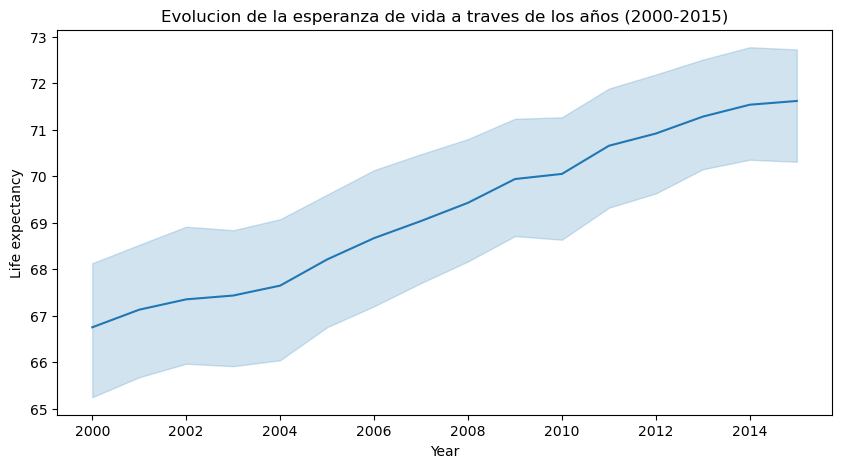

In [91]:
plt.figure(figsize=(10,5))

sns.lineplot(x='Year',y='Life expectancy',data=le)
plt.title('Evolucion de la esperanza de vida a traves de los años (2000-2015)')

In [92]:
# GRAFICO TOP PAISES POR MORTALIDAD 


In [93]:
top10= (
    le.groupby('Country')['Adult Mortality']
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
)

Text(0.5, 1.0, '10 paises con mayor tasa de mortalidad')

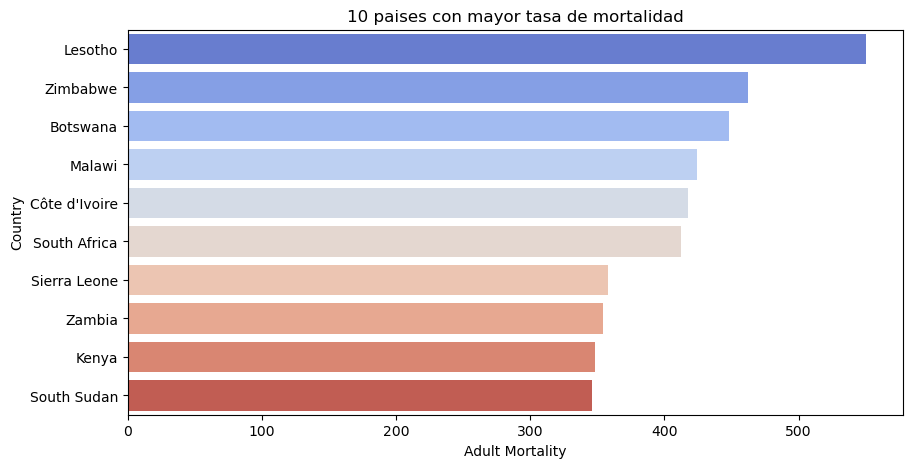

In [94]:
plt.figure(figsize=(10,5))

sns.barplot (
    data= top10,
    x= 'Adult Mortality',
    y='Country',
    palette= 'coolwarm',
    hue='Country',
    legend=False
)
plt.title('10 paises con mayor tasa de mortalidad')

## RESPUESTAS A LOS PLANTEOS 

*Luego de navegar y visualizar los datos del dataset, estamos en posicion de responder las preguntas que nos hicimos al comienzo 
del análisis*


La variable objetivo (Life expectancy) se relaciona fuertemente con estas otras variables:


**-Schooling** ( Años promedio de educación)

**-Income composition of resources** (Indice de desarrollo humano)

**-BMI** (Indice de masa corporal por poblacion)

**-GDP** (PBI Per Cápita en Dólares)


Y no solo eso, también encontramos fuertes relaciones entre variables interesantes, como:


**-Indice de desarrollo humano y schooling**

**-PBI Per Cápita y Gasto en salud**

**-Antagonismos de relacion entre variables como Indice de desarrollo humano y desnutrición**


Esta lectura de datos nos demuestra el motor principal de la esperanza de vida: **EL INDICE DE DESARROLLO HUMANO**. Con esto cerramos practicamente
todas las preguntas iniciales del análisis, pero, ¿Podemos crear un modelo que **PREDIGA** esta esperanza de vida?

In [95]:
# DEFINIMOS X E Y

In [96]:
y = le['Life expectancy'] # VARIABLE A PREDECIR

In [97]:
# SELECCIONAMOS FEATURES MAS IMPORTANTES PARA EL MODELO 
corr = le.corr(numeric_only=True)

corr['Life expectancy'].sort_values(ascending=False)

Life expectancy                    1.000000
Income composition of resources    0.818270
Schooling                          0.740796
BMI                                0.556901
Diphtheria                         0.472211
Polio                              0.458399
GDP                                0.430461
Alcohol                            0.388918
percentage expenditure             0.383016
Total expenditure                  0.208844
Year                               0.170819
Hepatitis B                        0.170219
Population                        -0.029014
Measles                           -0.157767
infant deaths                     -0.196769
under-five deaths                 -0.222738
thinness 5-9 years                -0.462473
thinness  1-19 years              -0.468002
HIV/AIDS                          -0.556703
Adult Mortality                   -0.696390
Name: Life expectancy, dtype: float64

In [98]:
X= le[['GDP','Schooling','BMI',
    'HIV/AIDS','Adult Mortality','thinness  1-19 years', 'thinness 5-9 years']]   # FEATURES

In [99]:
# SETEAMOS EL TEST DATA 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [100]:
# CREAMOS OBJETO DE REGRESION LINEAL
lm = LinearRegression()

In [101]:
# ENTRENAMOS NUESTRO MODELO 
lm.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [102]:
# OBTENEMOS COEFICIENTES
print("Coeficientes:", lm.coef_)

Coeficientes: [ 5.36944463e-05  1.37936931e+00  4.68315267e-02 -5.00353528e-01
 -2.14277922e-02 -8.01934411e-02 -4.83868462e-03]


In [103]:
# PREDECIMOS VALORES
predicciones = lm.predict(X_test)

Text(0, 0.5, 'PREDICCION Y')

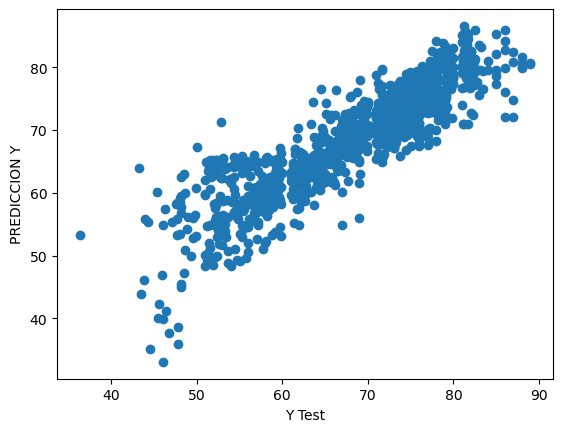

In [104]:
# VISUALIZAMOS VALORES REALES VS PREDECIDOS
plt.scatter(y_test,predicciones)
plt.xlabel('Y Test')
plt.ylabel('PREDICCION Y')

In [105]:
# CALCULAMOS METRICAS
print('MAE:', mean_absolute_error(y_test, predicciones))
print('MSE:', mean_squared_error(y_test, predicciones))
print('RMSE:', np.sqrt(mean_squared_error(y_test, predicciones)))
print('R2 SCORE:', r2_score(y_test,predicciones))

MAE: 3.1872298900038953
MSE: 19.151939130551117
RMSE: 4.376292852466699
R2 SCORE: 0.7910742997517529


<Axes: xlabel='Life expectancy', ylabel='Count'>

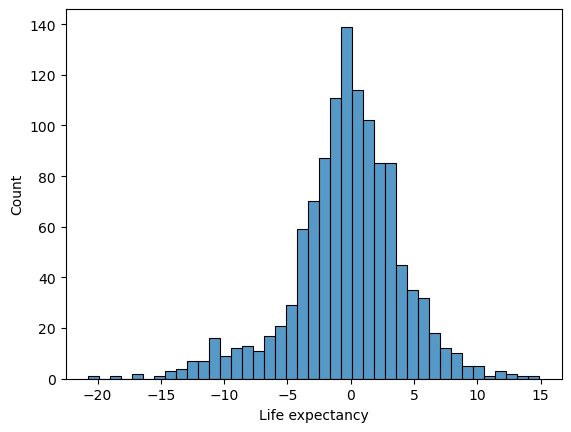

In [106]:
# VISUALIZAMOS RESIDUALES
sns.histplot(y_test-predicciones)

In [107]:
# ACLARAMOS COEFICIENTES
coeficientes = pd.DataFrame(lm.coef_,X.columns)
coeficientes.columns = ['Coeficientes']
coeficientes

,Coeficientes
GDP,0.000054
Schooling,1.379369
BMI,0.046832
HIV/AIDS,-0.500354
Adult Mortality,-0.021428
thinness 1-19 years,-0.080193
thinness 5-9 years,-0.004839


In [108]:
# VALIDAMOS NUESTRO MODELO CON VALIDACIÓN CRUZADA
lm_cv = LinearRegression()

# cv=5 significa 5 folds (splits)
# evaluamos en base la metrica de r2 score
scores_r2 = cross_val_score(lm_cv, X, y, cv=5, scoring='r2')
scores_mae = cross_val_score(lm_cv, X, y, cv=5, scoring='neg_mean_absolute_error')

print("R² por fold:", scores_r2.round(3))
print(f"R² promedio: {scores_r2.mean():.3f} ± {scores_r2.std():.3f}")
print()
print("MAE por fold:", (-scores_mae).round(3))
print(f"MAE promedio: {(-scores_mae).mean():.3f} ± {(-scores_mae).std():.3f}")


R² por fold: [0.815 0.759 0.798 0.752 0.722]
R² promedio: 0.769 ± 0.033

MAE por fold: [3.3   3.395 3.11  3.214 3.615]
MAE promedio: 3.327 ± 0.172


## ¿QUE ESTA HACIENDO ESTE MODELO?

Nuestro modelo de *REGRESIÓN LINEAL* toma las *FEATURES* con mayor correlación del dataset y las usa para
predecir valores de nuestra variable *TARGET* (Esperanza de vida)

## ¿POR QUÉ LA VALIDACIÓN CRUZADA?

Para no quedarnos con un solo resultado que podria interpretarse como "Afortunado" o "Inoportuno", dividimos el split en 5, para asi correr el modelo en 5 situaciones distintas. Luego, calculamos el r2_score de cada una y promediamos

Los resultados son los siguientes:

*R² por fold: [0.815 0.759 0.798 0.752 0.722]*

*R² promedio: 0.769 ± 0.033*

El R2 SCORE por cada fold (split) demuestra que no hay mucha diferencia entre 
ellos, por lo cual el modelo predice bien los resultados.

El promedio de R2 SCORE es de 0.769, con una desviacion estandar de 0.033.
**¿QUÉ SIGNIFICA?**

El modelo explica casi el 77% de la varianza de la esperanza de vida, esto quiere 
decir que es estable teniendo en cuenta la cantidad de variables que utiliza.


## INTERPRETACIÓN DE MÉTRICAS


| Métrica | Valor | Interpretación |
|--------|-------|----------------|
| MAE | 3.18 años | Error promedio del modelo. En promedio, predice con ±3.18 años de diferencia respecto al valor real. |
| MSE | 19.15 | Error cuadrático medio. Penaliza errores grandes. Unidad en años², sin interpretación directa. |
| RMSE | 4.37 años | Raíz del MSE, vuelve a la unidad original. Mayor que el MAE, lo que indica que existen algunos países donde el modelo comete errores considerables. |

Considerando que la esperanza de vida en el dataset varía entre 44 y 89 años 
(un rango de ~45 años), un MAE de 3.18 representa aproximadamente un 7% 
de error relativo — resultado aceptable para un modelo de regresión lineal 
con 7 variables sociosanitarias.


## CONCLUSIÓN FINAL

El análisis confirmó que la esperanza de vida es el resultado de un conjunto 
de condiciones estructurales interrelacionadas, no de un factor aislado.

En una primera versión del modelo se incluyó *Income composition of resources*, 
un índice compuesto que incorpora métricas de salud relacionadas al target, lo 
que generaba sesgo en los coeficientes e inflaba el R² artificialmente. Al 
eliminarlo, el modelo resultante es más honesto y sus coeficientes más 
interpretables.

El modelo de regresión lineal alcanzó un R² de 0.791, explicando aproximadamente 
el 79% de la varianza en la variable objetivo, con un error promedio de 3.19 años 
(MAE) sobre un rango de ~45 años — resultado sólido para un modelo lineal con 
7 variables.

El predictor de mayor peso fue Schooling (coef. +1.38), cuyo impacto real quedó 
visible al eliminar el IDH que lo opacaba. Cada año adicional de educación promedio 
se asocia a 1.38 años más de esperanza de vida. Notablemente, el GDP resultó casi 
irrelevante de forma directa (coef. +0.000054), sugiriendo que el dinero impacta 
en la esperanza de vida a través de lo que financia — educación y salud — y no 
por sí solo.

El HIV/AIDS resultó el factor negativo más determinante (coef. -0.50), explicando 
en parte por qué países del África subsahariana concentran las esperanzas de vida 
más bajas del dataset, independientemente de otras condiciones.

Como limitación, el modelo asume relaciones lineales y no captura efectos de 
interacción entre variables. Como próximo paso, explorar modelos como Random 
Forest permitiría identificar relaciones no lineales y potencialmente mejorar 
la capacidad predictiva.